# 02 - Tiền xử lý & Feature Engineering
## Phân tích lỗi sản xuất – UCI AI4I 2020 Predictive Maintenance

### Pipeline:
1. Load dữ liệu gốc
2. Xử lý missing / duplicates / outliers
3. Encoding biến phân loại
4. Feature Engineering: derived, bins, lag, rolling, interaction
5. Chuẩn hoá (scaling)
6. Lưu dữ liệu đã xử lý ra data/processed/

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from src.data.loader import load_params, load_raw_data, validate_schema
from src.data.cleaner import DataCleaner
from src.features.builder import FeatureBuilder

params = load_params('../configs/params.yaml')
print('Config loaded ✓')

Config loaded ✓


## 1. Load & Inspect Raw Data

In [2]:
df_raw = load_raw_data(path='../data/raw/ai4i2020.csv')
validate_schema(df_raw, params)

print(f'Shape: {df_raw.shape}')
print(f'Missing: {df_raw.isnull().sum().sum()}')
print(f'Duplicates: {df_raw.duplicated().sum()}')
df_raw.head(3)

[loader] Loaded raw data: 10000 rows, 14 columns
[loader] Schema validation passed ✓
Shape: (10000, 14)
Missing: 0
Duplicates: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


## 2. Tiền xử lý (Cleaning)

Các bước:
- Xử lý missing values (nếu có)
- Loại bỏ duplicates
- Clip outliers bằng IQR
- One-hot encode biến Type

In [3]:
# Tạo bản sao để giữ raw cho các task khác
df = df_raw.copy()

# Thống kê TRƯỚC xử lý
print('=== TRƯỚC Tiền xử lý ===')
print(f'Shape: {df.shape}')
print(f'Missing: {df.isnull().sum().sum()}')
numeric_cols = params['data']['numeric_features']
print(f'\nThống kê numeric features:')
display(df[numeric_cols].describe().round(2))

=== TRƯỚC Tiền xử lý ===
Shape: (10000, 14)
Missing: 0

Thống kê numeric features:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


In [4]:
# Chạy DataCleaner (CHƯA scale – scale riêng theo train/test)
# Tạm thời clean: missing, duplicates, outliers, encoding
cleaner = DataCleaner(params)

# Xử lý từng bước để kiểm soát
df = cleaner.handle_missing(df)
df = cleaner.handle_duplicates(df)
df = cleaner.handle_outliers(df)
df = cleaner.encode_categorical(df, fit=True)

print(f'\n=== SAU Tiền xử lý ===')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

[cleaner] No missing values found ✓
[cleaner] No duplicates found ✓
[cleaner] Clipped 487 outlier values (iqr)
[cleaner] One-Hot encoded: ['Type']

=== SAU Tiền xử lý ===
Shape: (10000, 16)
Columns: ['UDI', 'Product ID', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M']


=== Thống kê SAU xử lý ===


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1530.14,39.98,107.95
std,2.0,1.48,148.80,9.91,63.65
min,295.3,305.70,1168.00,12.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,1895.50,67.20,253.00


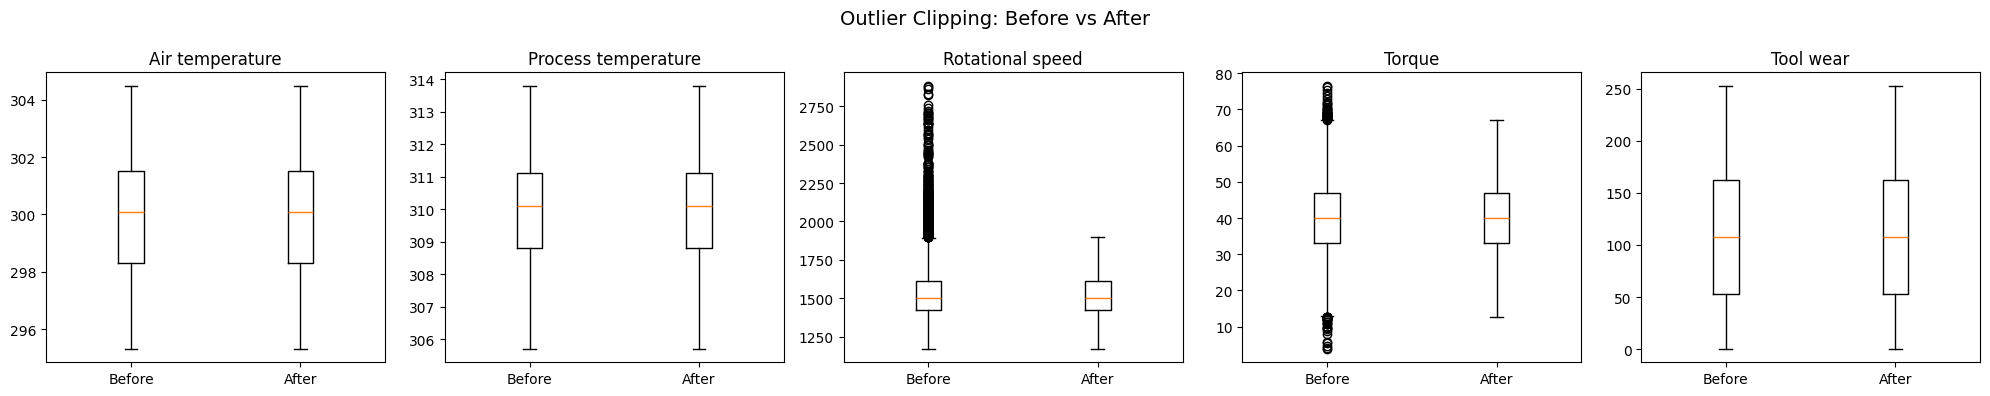

In [5]:
# So sánh thống kê trước-sau outlier clipping
print('=== Thống kê SAU xử lý ===')
numeric_cols_available = [c for c in numeric_cols if c in df.columns]
display(df[numeric_cols_available].describe().round(2))

# Visualize trước-sau
fig, axes = plt.subplots(1, len(numeric_cols_available), figsize=(4*len(numeric_cols_available), 4))
for i, col in enumerate(numeric_cols_available):
    axes[i].boxplot([df_raw[col].values, df[col].values], labels=['Before', 'After'])
    axes[i].set_title(col.split('[')[0].strip())
plt.suptitle('Outlier Clipping: Before vs After', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/02_outlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [6]:
# Feature engineering
builder = FeatureBuilder(params)
df_feat = builder.build(df)

print(f'\nShape after feature engineering: {df_feat.shape}')
print(f'Total features: {len(builder.get_feature_names())}')
print(f'\nNew columns added:')
new_cols = set(df_feat.columns) - set(df.columns)
print(sorted(new_cols))

[builder] Created: temp_diff
[builder] Created: power (Watt)
[builder] Created: torque_speed_ratio
[builder] Created: wear_torque
[builder] Binned Tool wear into 5 categories
[builder] Created 20 lag features (windows: [1, 3, 5, 10])
[builder] Created 30 rolling features (windows: [5, 10, 20])
[builder] Created 69 features total

Shape after feature engineering: (10000, 77)
Total features: 69

New columns added:
['Air temperature [K]_lag1', 'Air temperature [K]_lag10', 'Air temperature [K]_lag3', 'Air temperature [K]_lag5', 'Air temperature [K]_rmean10', 'Air temperature [K]_rmean20', 'Air temperature [K]_rmean5', 'Air temperature [K]_rstd10', 'Air temperature [K]_rstd20', 'Air temperature [K]_rstd5', 'Process temperature [K]_lag1', 'Process temperature [K]_lag10', 'Process temperature [K]_lag3', 'Process temperature [K]_lag5', 'Process temperature [K]_rmean10', 'Process temperature [K]_rmean20', 'Process temperature [K]_rmean5', 'Process temperature [K]_rstd10', 'Process temperature [

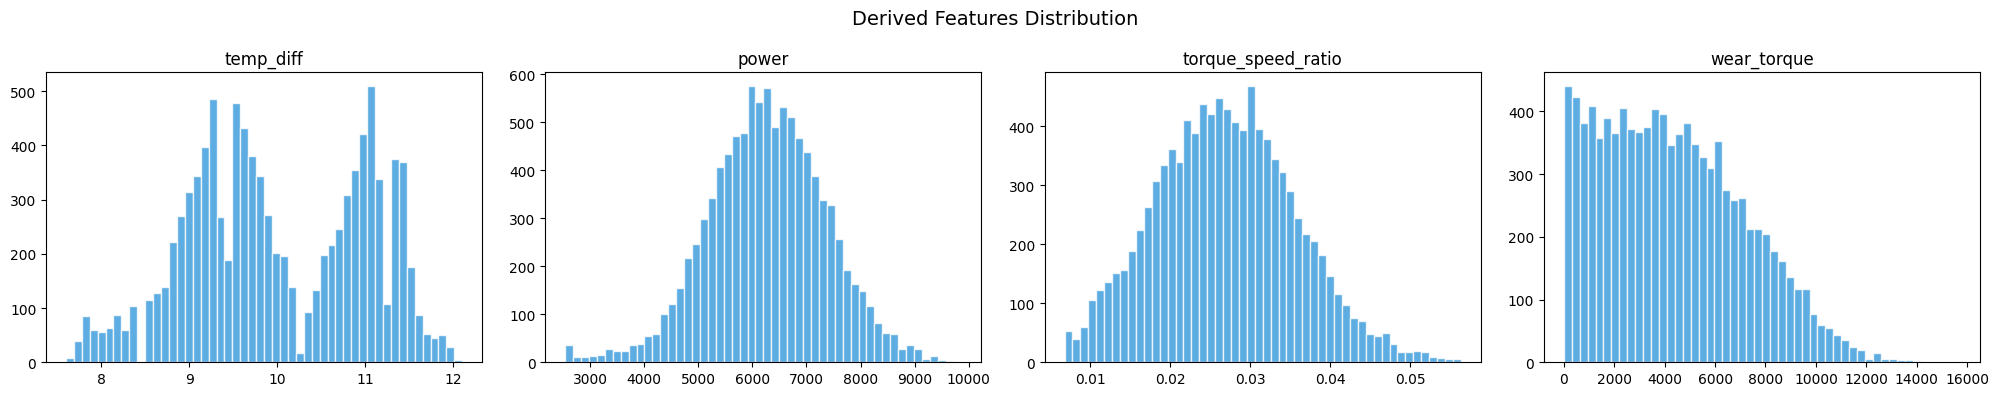

In [7]:
# Phân bố derived features
derived = ['temp_diff', 'power', 'torque_speed_ratio', 'wear_torque']
derived_available = [c for c in derived if c in df_feat.columns]

fig, axes = plt.subplots(1, len(derived_available), figsize=(5*len(derived_available), 4))
if len(derived_available) == 1:
    axes = [axes]
for i, col in enumerate(derived_available):
    axes[i].hist(df_feat[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
plt.suptitle('Derived Features Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/02_derived_features.png', dpi=150, bbox_inches='tight')
plt.show()

Tool wear bin distribution:
  tw_bin_very_low: 2396
  tw_bin_low: 2271
  tw_bin_medium: 2295
  tw_bin_high: 2276
  tw_bin_very_high: 762


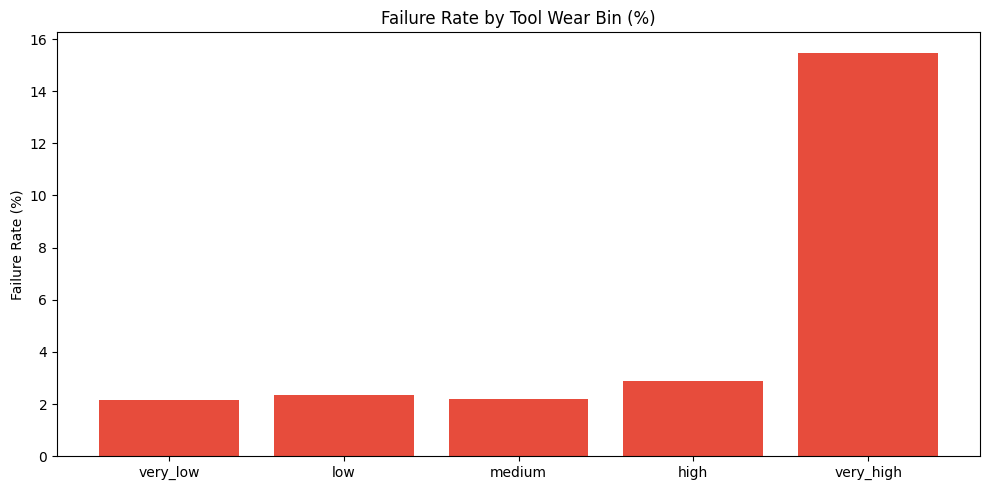

In [8]:
# Tool wear bins distribution
tw_bin_cols = [c for c in df_feat.columns if c.startswith('tw_bin_')]
if tw_bin_cols:
    print('Tool wear bin distribution:')
    for col in tw_bin_cols:
        print(f'  {col}: {df_feat[col].sum()}')
    
    # Failure rate by tool wear bin
    fig, ax = plt.subplots(figsize=(10, 5))
    rates = []
    for col in tw_bin_cols:
        mask = df_feat[col] == 1
        if mask.sum() > 0:
            rate = df_feat.loc[mask, 'Machine failure'].mean() * 100
        else:
            rate = 0
        rates.append(rate)
    labels = [c.replace('tw_bin_', '') for c in tw_bin_cols]
    ax.bar(labels, rates, color='#e74c3c')
    ax.set_title('Failure Rate by Tool Wear Bin (%)')
    ax.set_ylabel('Failure Rate (%)')
    plt.tight_layout()
    plt.savefig('../outputs/figures/02_failure_by_tool_wear_bin.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Chuẩn bị dữ liệu cho Modeling

In [9]:
# Xác định feature columns cho classification
# QUAN TRỌNG: Loại bỏ failure type columns (TWF, HDF, PWF, OSF, RNF) để tránh data leakage
id_cols = ['UDI', 'Product ID']
target_col = 'Machine failure'
leakage_cols = params['data']['failure_types']  # TWF, HDF, PWF, OSF, RNF

exclude_cols = [c for c in id_cols + [target_col] + leakage_cols if c in df_feat.columns]
feature_cols = [c for c in df_feat.columns if c not in exclude_cols]

print(f'Feature columns ({len(feature_cols)}):')
print(feature_cols)
print(f'\nTarget: {target_col}')
print(f'Excluded (leakage): {leakage_cols}')

Feature columns (69):
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M', 'temp_diff', 'power', 'torque_speed_ratio', 'wear_torque', 'tw_bin_very_low', 'tw_bin_low', 'tw_bin_medium', 'tw_bin_high', 'tw_bin_very_high', 'Air temperature [K]_lag1', 'Air temperature [K]_lag3', 'Air temperature [K]_lag5', 'Air temperature [K]_lag10', 'Process temperature [K]_lag1', 'Process temperature [K]_lag3', 'Process temperature [K]_lag5', 'Process temperature [K]_lag10', 'Rotational speed [rpm]_lag1', 'Rotational speed [rpm]_lag3', 'Rotational speed [rpm]_lag5', 'Rotational speed [rpm]_lag10', 'Torque [Nm]_lag1', 'Torque [Nm]_lag3', 'Torque [Nm]_lag5', 'Torque [Nm]_lag10', 'Tool wear [min]_lag1', 'Tool wear [min]_lag3', 'Tool wear [min]_lag5', 'Tool wear [min]_lag10', 'Air temperature [K]_rmean5', 'Air temperature [K]_rstd5', 'Air temperature [K]_rmean10', 'Air temperature [K]_rstd10', 'Air temperature [K]_rmean20

In [10]:
# Kiểm tra NaN sau feature engineering
nan_count = df_feat[feature_cols].isnull().sum().sum()
print(f'NaN in features: {nan_count}')
if nan_count > 0:
    # Fill remaining NaN
    df_feat[feature_cols] = df_feat[feature_cols].fillna(0)
    print('Filled remaining NaN with 0')

print(f'\nFinal shape: {df_feat.shape}')
print(f'Feature matrix: ({len(df_feat)}, {len(feature_cols)})')

NaN in features: 0

Final shape: (10000, 77)
Feature matrix: (10000, 69)


## 5. Lưu dữ liệu đã xử lý

In [11]:
# Lưu processed data
os.makedirs('../data/processed', exist_ok=True)

# Parquet (ưu tiên)
df_feat.to_parquet('../data/processed/ai4i2020_processed.parquet', index=False)
print('Saved: data/processed/ai4i2020_processed.parquet')

# CSV backup
df_feat.to_csv('../data/processed/ai4i2020_processed.csv', index=False)
print('Saved: data/processed/ai4i2020_processed.csv')

# Lưu feature list
import json
feature_info = {
    'feature_cols': feature_cols,
    'target_col': target_col,
    'leakage_cols': leakage_cols,
    'id_cols': id_cols,
}
with open('../data/processed/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print('Saved: data/processed/feature_info.json')

print(f'\n✓ Pipeline complete. Processed data shape: {df_feat.shape}')

Saved: data/processed/ai4i2020_processed.parquet


Saved: data/processed/ai4i2020_processed.csv
Saved: data/processed/feature_info.json

✓ Pipeline complete. Processed data shape: (10000, 77)
